<a href="https://colab.research.google.com/github/JoyMuthoniNjeru/AI-Coursework-2025/blob/main/Diamonds_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Group 4: Brainstack :)

In [52]:
from google.colab import files
import pandas as pd

diamonds = pd.read_csv("/content/diamonds.zip")


Q1: Cleaning The Dataset:

In [53]:
#inspect data
diamonds.head()
diamonds.info()
diamonds.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [54]:
#handle missing & inconsistent data
diamonds.isnull().sum()

diamonds = diamonds.dropna()

In [55]:
#check for duplicate rows
diamonds.duplicated().sum()

#remove duplicate rows
diamonds = diamonds.drop_duplicates()

Q2: Exploratory Data Analysis

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

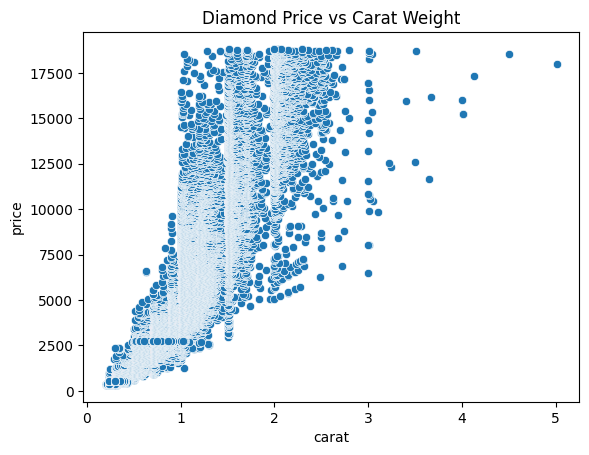

In [57]:
#check rlship between price and carat
sns.scatterplot(x='carat', y='price', data=diamonds)
plt.title('Diamond Price vs Carat Weight')
plt.show()

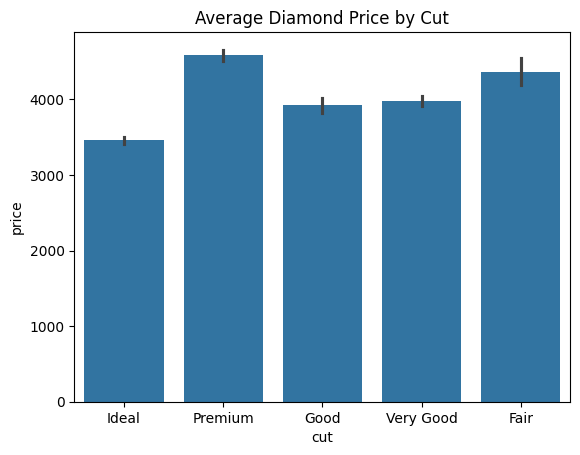

In [58]:
#check rlship between average price and cut
sns.barplot(x='cut', y='price', data=diamonds, estimator=np.mean)
plt.title('Average Diamond Price by Cut')
plt.show()

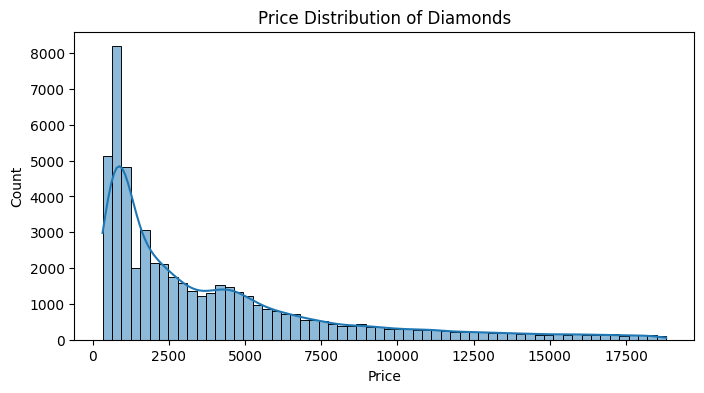

In [59]:
# Price Distribution
plt.figure(figsize=(8,4))
sns.histplot(diamonds['price'], bins=60, kde=True)
plt.title("Price Distribution of Diamonds")
plt.xlabel("Price")
plt.show()

Insights retrieved:
1. Bigger diamonds tend to cost more but diamons with the same carat can still have very different prices depending on quality.
2. Premium and fair cuts have higher prices than others.
3. Affordable diamonds are more common while expensive ones are less frequent

In [60]:
#random sample of 12500 randomly selected records
diamonds_model = diamonds.sample(n=12500, random_state=42)
diamonds_model.shape

(12500, 11)

Q3: Predicting Prices Using Linear Regression

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [62]:
#label encode categorical columns
df_simple = diamonds_model.copy()

categorical_cols = ['cut', 'color', 'clarity']
label_encoder = LabelEncoder()

for col in categorical_cols:
    df_simple[col] = label_encoder.fit_transform(df_simple[col])

In [63]:
#split data
from sklearn.model_selection import train_test_split

X = df_simple.drop('price', axis=1)
y = df_simple['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
#linear regression model
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [65]:
#predictions and evaluations
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = lr_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print("R-squared:", r2)
print("RMSE:", rmse)


R-squared: 0.8902383826382018
RMSE: 1740869.1993157594


We used linear regression to predict diamonds prices using all features

Q4: PCA to select continuous predictors & re-model

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [67]:
#select continuous columns
continuous_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
X_cont = diamonds_model[continuous_cols]

In [68]:
#standardize data for PCA
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X_cont)

In [69]:
#PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [70]:
#re-model with PCA features only
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

pca_model = LinearRegression()
pca_model.fit(X_train_pca, y_train)

y_pred_pca = pca_model.predict(X_test_pca)

#evaluate
r2_pca = r2_score(y_test, y_pred_pca)
rmse_pca = mean_squared_error(y_test, y_pred_pca)

print("R-squared (PCA):", r2_pca)
print("RMSE (PCA):", rmse_pca)

R-squared (PCA): 0.8055772996058582
RMSE (PCA): 3083632.50195471


The PCA model uses only 2 transformed features that capture the most variance. We expect lower accuracy because this reduces much of the original information

Q5: Apply Lasso and Ridge regularisation techniques

In [71]:
from sklearn.linear_model import Lasso, Ridge

#Lasso model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

#evaluate
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = mean_squared_error(y_test, y_pred_lasso)

print("Lasso - R-squared:", r2_lasso)
print("Lasso - RMSE:", rmse_lasso)



Lasso - R-squared: 0.8901625513850053
Lasso - RMSE: 1742071.9174991127


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.716e+09, tolerance: 1.577e+07
  model = cd_fast.enet_coordinate_descent(


In [72]:
#Ridge model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

#evaluate
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("Ridge - R-squared:", r2_ridge)
print("Ridge - RMSE:", rmse_ridge)

Ridge - R-squared: 0.8902287462334153
Ridge - RMSE: 1741022.0370808006


Q6: Comparison and Conclusion

1. Linear regression with all features - Highest or near highest R^2

2. PCA regression (2 components) - Lowest accuracy; information lost

3. Lasso regression - similar to linear regrssion, sometimes slightly lower

4. Ridge regression - often performs slightly better than Lasso

The likely lead to this performance is either Linear regression or Ridge regression because they retain all useful feature information while controlling overfitting.

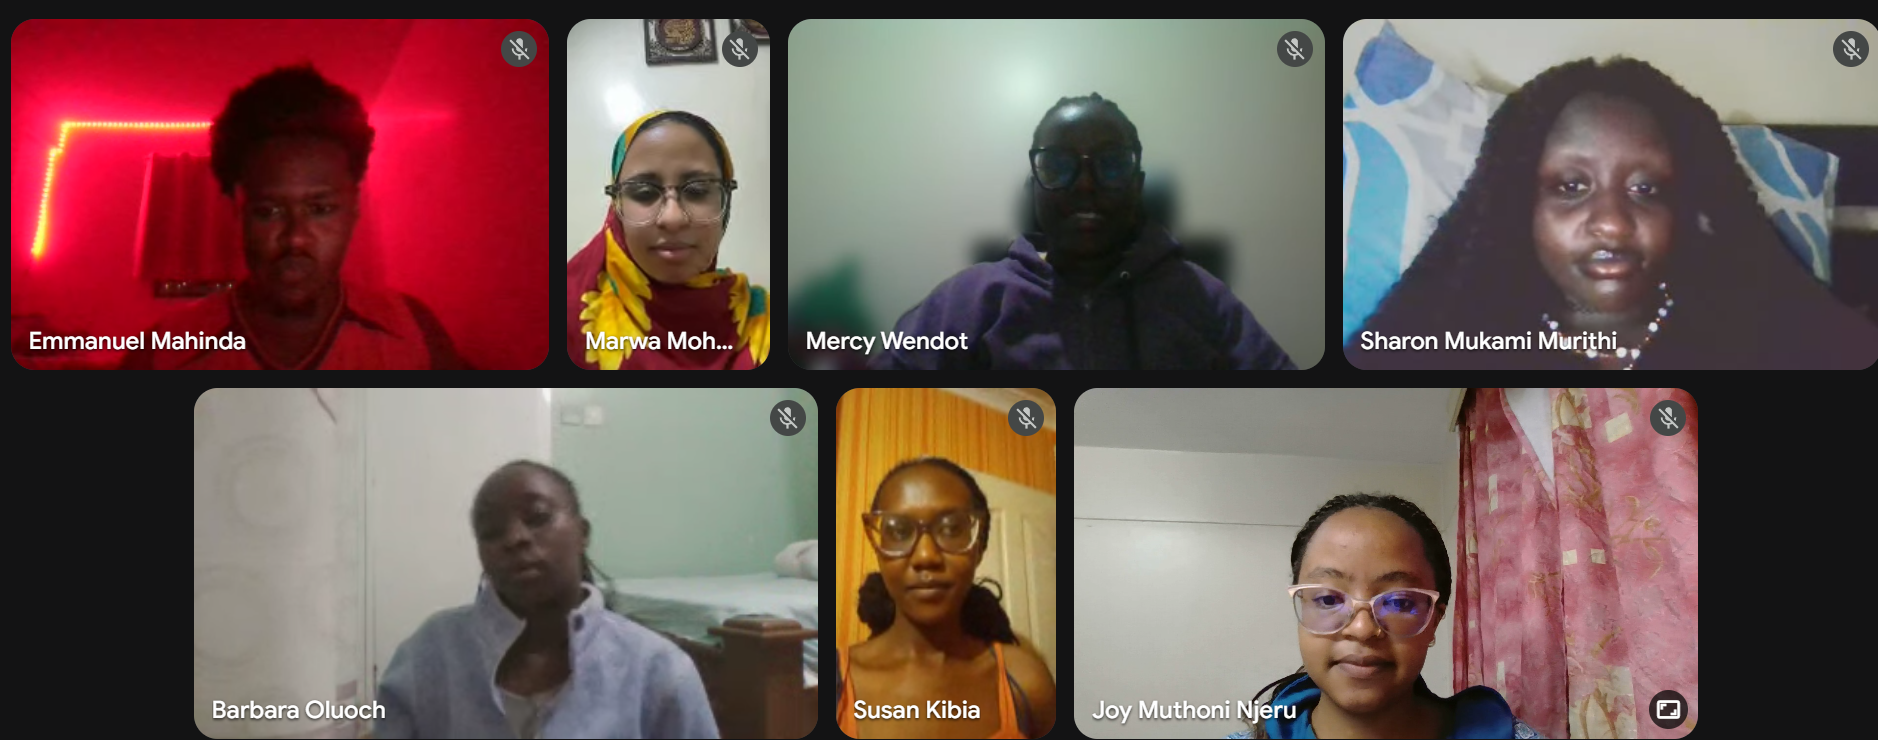